#**Analisis Sistem WPT Tanpa Kapasitor Kompensasi**

Gambar Rangkaian:
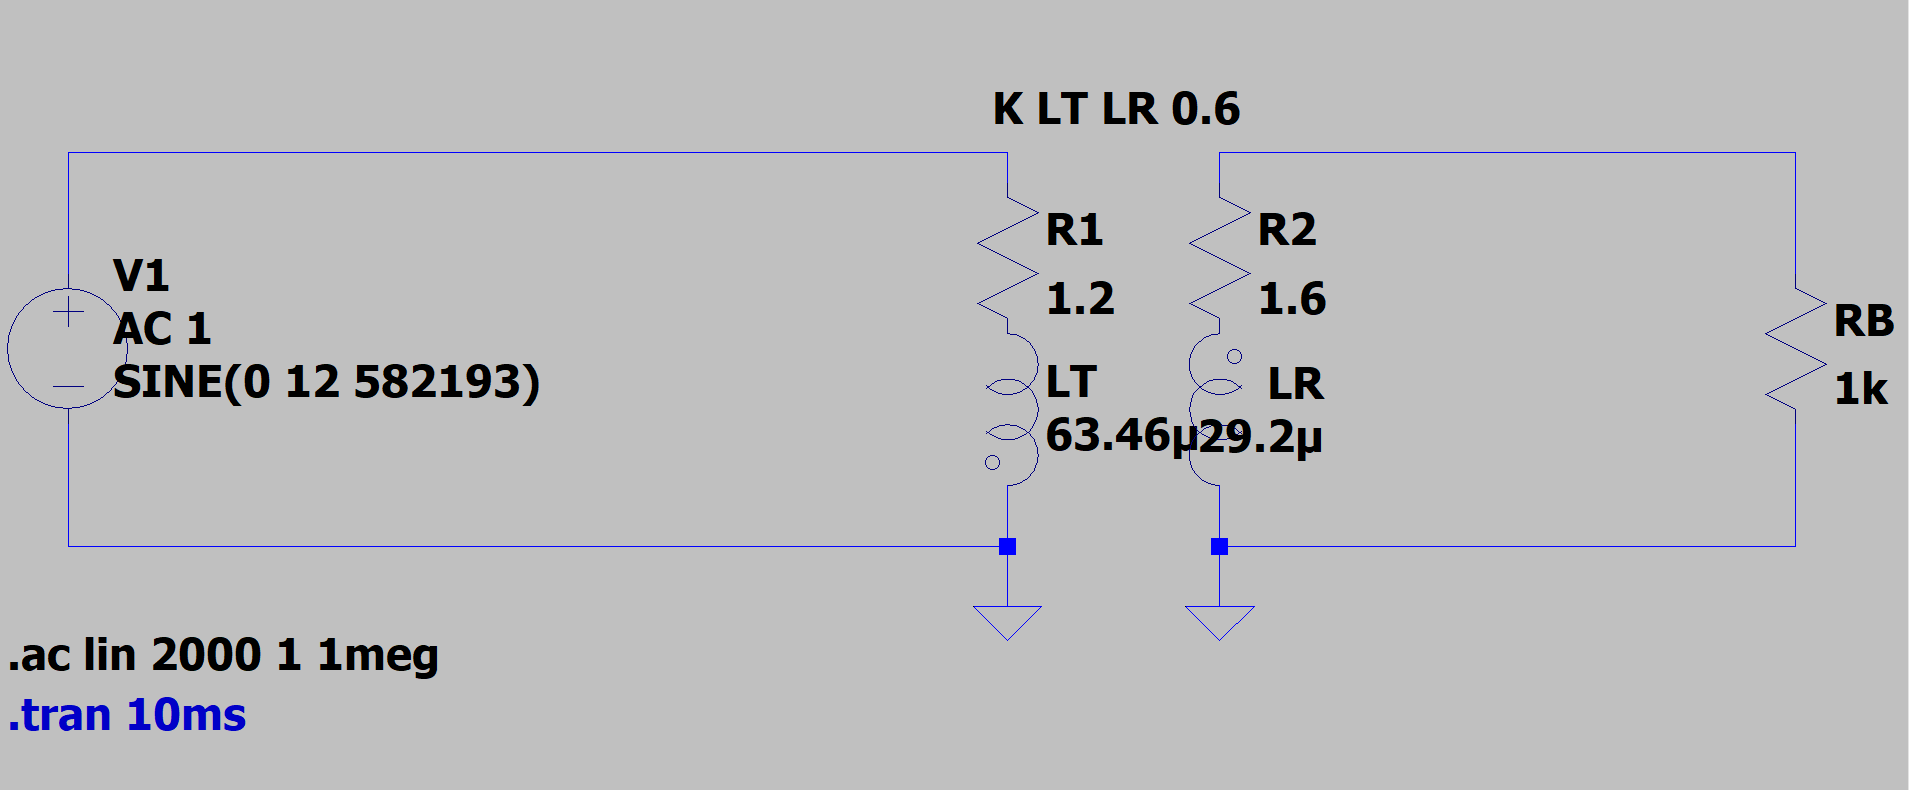

#**KCL & KVL Analysis (Analisis Arus dan Tegangan)**

**Tujuan:** Pada bagian ini dilakukan analisis terhadap rangkaian dasar Wireless Power Transfer tanpa kapasitor kompensasi, menggunakan hukum-hukum dasar rangkaian, yaitu KVL (Kirchhoff's Voltage Law) dan KCL (Kirchhoff's Current Law). Hasil dari analisis ini berupa model matematis berbasis persamaan simbolik arus dan tegangan.

**KVL (Kirchhoff Voltage Law)**

Untuk rangkaian kopling induktif dua lilitan dengan kopling mutual
𝑀, kita memiliki dua loop:

**Loop Primer:**

\begin{aligned}
V_1 = I_1(R_1 + sL_1) - sM \cdot I_2
\end{aligned}

**Loop Sekunder:**

\begin{aligned}
0 = I_2(R_2 + R_B + sL_2) - sM \cdot I_1
\end{aligned}

Dengan:
\begin{aligned}
R_1, R_2 &: \text{Resistansi lilitan primer dan sekunder} \\
L_1, L_2 &: \text{Induktansi lilitan primer dan sekunder} \\
R_B &: \text{Resistansi beban} \\
M &= k \sqrt{L_1 L_2} \quad \text{(induktansi mutual)} \\
s &: \text{Variabel kompleks Laplace} \\
I_1, I_2 &: \text{Arus pada sisi primer dan sekunder} \\
V_1 &: \text{Tegangan input dari sumber}
\end{aligned}

**Persamaan Matriks Impedansi**

\begin{bmatrix}
R_1 + sL_1 & -sM \\
-sM & R_2 + R_B + sL_2
\end{bmatrix}
\begin{bmatrix}
I_1 \\
I_2
\end{bmatrix}
=
\begin{bmatrix}
V_1 \\
0
\end{bmatrix}

Solusi dari sistem ini akan memberikan ekspresi simbolik dari
$I_1(s)$ dan $I_2(s)$, yang menjadi dasar untuk turunan transfer function dan state space model.


In [6]:
import sympy as sp
from sympy.abc import s
from IPython.display import display, Math

# Parameter simbolik
R1, R2, RB = 1.2, 1.6, 1000  # Ohm
L1_val, L2_val = 63.46e-6, 29.2e-6  # Henry

# Variabel simbolik
L1, L2, M = sp.symbols('L1 L2 M', real=True)
I1, I2, V1 = sp.symbols('I1 I2 V1')

In [7]:
# Matriks impedansi
Z11 = R1 + s*L1
Z22 = R2 + RB + s*L2
Z12 = Z21 = -s*M

# Matriks sistem
Z = sp.Matrix([[Z11, Z12],
               [Z21, Z22]])
I = sp.Matrix([I1, I2])
V = sp.Matrix([V1, 0])  # Tegangan sisi sekunder = 0 (tidak ada sumber di sana)

# Selesaikan sistem: I = Z⁻¹ * V
solusi_arus = sp.simplify(Z.inv() * V)
I1_sol, I2_sol = solusi_arus[0], solusi_arus[1]

# Tampilkan solusi
display(Math(r"I_1 = " + sp.latex(I1_sol)))
display(Math(r"I_2 = " + sp.latex(I2_sol)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#**State Space Modeling**

**Tujuan:** Menyusun model State Space berdasarkan sistem dua loop dari WPT induktif:

\begin{align*}
V_1 &= I_1(R_1 + sL_1) - sM I_2 \\
0 &= I_2(R_2 + R_B + sL_2) - sM I_1
\end{align*}

Kita akan transformasi ke bentuk:

$$
\dot{x} = A x + B u,\quad \text{dengan} \quad x = \begin{bmatrix} i_1 \\ i_2 \end{bmatrix},\quad u = V_1
$$



**Definisi Matriks State Space**

In [11]:
import sympy as sp
from sympy.abc import t

# Definisi simbolik
R1, R2, RB = sp.symbols('R1 R2 RB', real=True, positive=True)
L1, L2, M = sp.symbols('L1 L2 M', real=True, positive=True)
V1 = sp.symbols('V1')
I1, I2 = sp.Function('I1')(t), sp.Function('I2')(t)

# Turunan arus
dI1 = sp.diff(I1, t)
dI2 = sp.diff(I2, t)

# Persamaan dari KVL (loop primer dan sekunder)
eq1 = sp.Eq(V1, I1*R1 + L1*dI1 - M*dI2)
eq2 = sp.Eq(0, I2*(R2 + RB) + L2*dI2 - M*dI1)

# Selesaikan untuk turunan (state equations)
sol = sp.solve([eq1, eq2], (dI1, dI2))
di1_dt = sol[sp.diff(I1, t)]
di2_dt = sol[sp.diff(I2, t)]

display(sp.Eq(sp.Symbol('di1/dt'), di1_dt))
display(sp.Eq(sp.Symbol('di2/dt'), di2_dt))

Eq(di1/dt, -L2*R1*I1(t)/(L1*L2 - M**2) + L2*V1/(L1*L2 - M**2) - M*R2*I2(t)/(L1*L2 - M**2) - M*RB*I2(t)/(L1*L2 - M**2))

Eq(di2/dt, -L1*R2*I2(t)/(L1*L2 - M**2) - L1*RB*I2(t)/(L1*L2 - M**2) - M*R1*I1(t)/(L1*L2 - M**2) + M*V1/(L1*L2 - M**2))

In [12]:
# Vektor keadaan
x = sp.Matrix([I1, I2])

# Matriks A
A = sp.Matrix([
    [sp.diff(di1_dt, I1), sp.diff(di1_dt, I2)],
    [sp.diff(di2_dt, I1), sp.diff(di2_dt, I2)]
])

# Matriks B
B = sp.Matrix([
    [sp.diff(di1_dt, V1)],
    [sp.diff(di2_dt, V1)]
])

# Tampilkan hasil
display(sp.Eq(sp.Symbol('A'), A))
display(sp.Eq(sp.Symbol('B'), B))

False

False

### State Space Model

Bentuk umum sistem linier:

$\dot{x}$ = Ax + Bu
dengan x =
\begin{bmatrix}
i_1 \\
i_2
\end{bmatrix}, u = $V_1$
\]

Dengan A dan B adalah:

\[
A =
\begin{bmatrix}
\frac{\partial \dot{i_1}}{\partial i_1} & \frac{\partial \dot{i_1}}{\partial i_2} \\
\frac{\partial \dot{i_2}}{\partial i_1} & \frac{\partial \dot{i_2}}{\partial i_2}
\end{bmatrix},
B =
\begin{bmatrix}
\frac{\partial \dot{i_1}}{\partial V_1} \\
\frac{\partial \dot{i_2}}{\partial V_1}
\end{bmatrix}
\]

**Transfer Function**

**Tujuan:** Mencari fungsi alih (Transfer Function) dalam domain Laplace:

$H(s) = \frac{I_2(s)}{V_1(s)}$



**- Matriks Impedansi**

$$
\begin{bmatrix}
R_1 + sL_1 & -sM \\
-sM & R_2 + R_B + sL_2
\end{bmatrix}
\begin{bmatrix}
I_1(s) \\
I_2(s)
\end{bmatrix}
=
\begin{bmatrix}
V_1(s) \\
0
\end{bmatrix}
$$

In [13]:
import sympy as sp
from sympy.abc import s
from IPython.display import display, Math

# Simbol simbolik
R1, R2, RB = sp.symbols('R1 R2 RB', real=True, positive=True)
L1, L2, M = sp.symbols('L1 L2 M', real=True, positive=True)
I1, I2, V1 = sp.symbols('I1 I2 V1')

# Elemen matriks impedansi
Z11 = R1 + s*L1
Z12 = -s*M
Z21 = -s*M
Z22 = R2 + RB + s*L2

# Matriks sistem
Z = sp.Matrix([[Z11, Z12],
               [Z21, Z22]])
V = sp.Matrix([V1, 0])

# Solusi arus
I = Z.inv() * V

# Fungsi alih: I2 / V1
H_s = sp.simplify(I[1] / V1)
display(Math(r"H(s) = \frac{I_2(s)}{V_1(s)} = " + sp.latex(H_s)))

<IPython.core.display.Math object>

### Fungsi Alih (Transfer Function)

Dari hasil penyelesaian sistem matriks impedansi, kita memperoleh:

$H(s) = \frac{I_2(s)}{V_1(s)}$ = fungsi alih dari rangkaian WPT induktif tanpa kompensasi

$
Z(s)$ =
\begin{bmatrix}
R_1 + sL_1 & -sM \\
-sM & R_2 + R_B + sL_2
\end{bmatrix}
$I(s) = Z(s)^{-1} \cdot V(s)$

Komponen fungsi alih:
- Input: $V_1(s)$
- Output: $I_2(s)$
- Transfer function: $H(s) = \frac{I_2(s)}{V_1(s)}$

#**Analisis Respon Frekuensi**

**Tujuan:** Pada bagian ini dilakukan analisis terhadap respon frekuensi dari sistem Wireless Power Transfer (WPT) tanpa kapasitor kompensasi. Fokus utamanya adalah untuk memahami bagaimana sistem merespons sinyal masukan AC dengan berbagai frekuensi dan seberapa efisien daya ditransfer dari sisi primer ke sekunder pada masing-masing frekuensi.

Respon frekuensi didasarkan pada fungsi alih yang sebelumnya telah diperoleh:

$$
H(s) = \frac{I_2(s)}{V_1(s)}
$$

Untuk analisis frekuensi, kita evaluasi fungsi alih pada domain
$s = j\omega$, sehingga diperoleh:
 $$
H(j\omega) = \frac{I_2(j\omega)}{V_1(j\omega)}
$$

Dengan:

$$
\omega = 2\pi f
$$
𝑓: frekuensi dalam Hertz

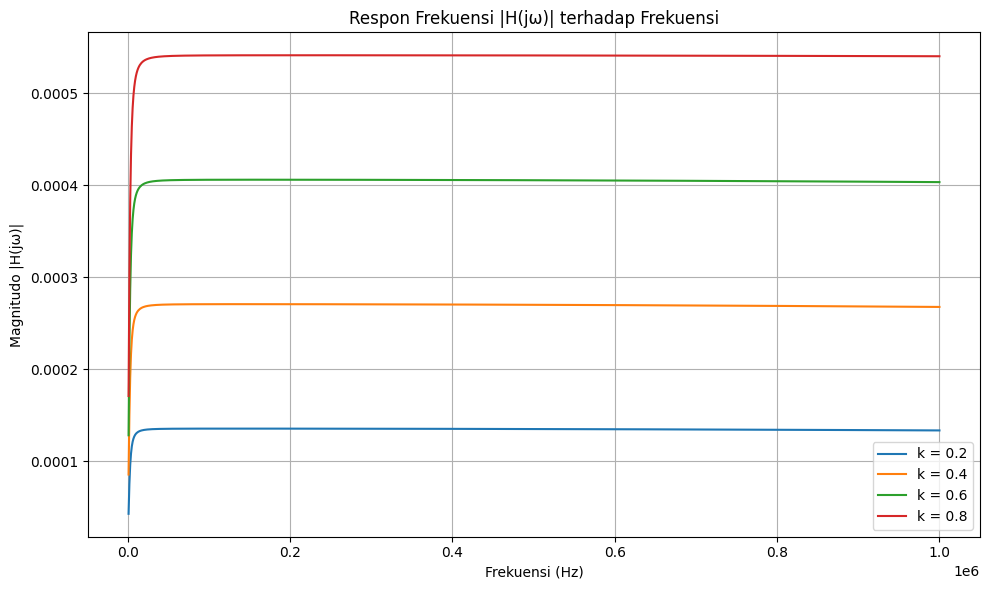

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Nilai komponen numerik
L1_val = 63.46e-6  # Henry
L2_val = 29.2e-6   # Henry
R1_val = 1.2       # Ohm
R2_val = 1.6       # Ohm
RB_val = 1000      # Ohm

# Substitusi simbolik ke fungsi alih
H_num = H_s.subs({
    R1: R1_val,
    R2: R2_val,
    RB: RB_val,
    L1: L1_val,
    L2: L2_val,
})

# Fungsi untuk berbagai nilai k
k_values = [0.2, 0.4, 0.6, 0.8]
frequencies = np.linspace(1e3, 1e6, 1000)
omega = 2 * np.pi * frequencies

plt.figure(figsize=(10,6))

for k in k_values:
    M_val = k * np.sqrt(L1_val * L2_val)
    H_k = H_num.subs(M, M_val)
    H_func = sp.lambdify(s, H_k, 'numpy')
    H_freq = np.abs(H_func(1j * omega))

    plt.plot(frequencies, H_freq, label=f'k = {k}')

plt.title("Respon Frekuensi |H(jω)| terhadap Frekuensi")
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("Magnitudo |H(jω)|")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Respon Frekuensi (Frequency Response)

Dengan substitusi parameter numerik dan variasi koefisien kopling \(k\), didapatkan grafik respon frekuensi dari fungsi alih:

$H(s) = \frac{I_2(s)}{V_1(s)}$

Variabel $M = k \sqrt{L_1 L_2}$ mempengaruhi besarnya kopling antara lilitan primer dan sekunder. Grafik di bawah menunjukkan bagaimana $k$ mempengaruhi bentuk respon frekuensi dari sistem.

Semakin besar $k$, maka peak power transfer terjadi lebih besar dan lebih tajam (resonansi lebih kuat).

#**Analisis Respon Waktu**

**Tujuan:** Menganalisis respon waktu sistem berdasarkan fungsi alih
$H(s) = \frac{I_2(s)}{V_1(s)}$, untuk memahami dinamika sistem terhadap input seperti step atau sinusoidal, serta bagaimana koefisien kopling
𝑘 memengaruhi bentuk responnya.

**Simulasi Respon Waktu**

Karena fungsi alih sudah dalam bentuk simbolik, kita akan konversi ke bentuk numerik (koefisien polinomial) dan gunakan scipy.signal untuk melakukan simulasi waktu.

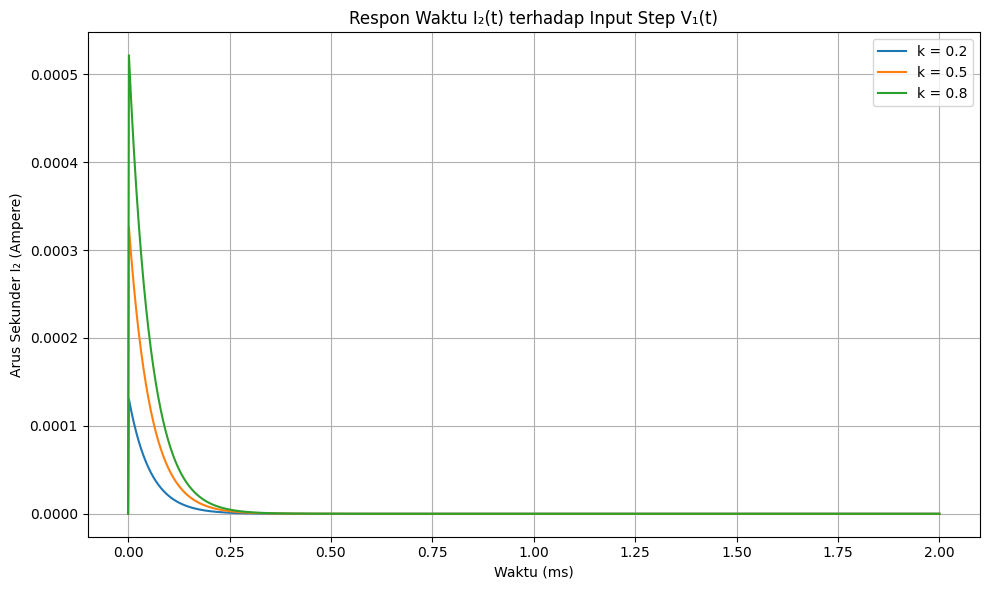

In [15]:
from scipy.signal import TransferFunction, step, lti
import numpy as np
import matplotlib.pyplot as plt

# --- Nilai komponen ---
L1_val = 63.46e-6
L2_val = 29.2e-6
R1_val = 1.2
R2_val = 1.6
RB_val = 1000

# Variasi nilai k
k_values = [0.2, 0.5, 0.8]

# Waktu simulasi
t = np.linspace(0, 0.002, 1000)  # 2 ms total

plt.figure(figsize=(10, 6))

for k in k_values:
    M_val = k * np.sqrt(L1_val * L2_val)

    # Substitusi ke fungsi alih
    H_num_k = H_s.subs({
        R1: R1_val, R2: R2_val, RB: RB_val,
        L1: L1_val, L2: L2_val,
        M: M_val
    })

    # Ekstrak numerator dan denominator
    num, den = sp.fraction(H_num_k.simplify())
    num_coeffs = sp.Poly(num, s).all_coeffs()
    den_coeffs = sp.Poly(den, s).all_coeffs()

    # Konversi ke float
    num_coeffs = [float(c) for c in num_coeffs]
    den_coeffs = [float(c) for c in den_coeffs]

    # Buat transfer function dan simulasi step response
    system = TransferFunction(num_coeffs, den_coeffs)
    t_out, i2_response = step(system, T=t)

    plt.plot(t_out*1000, i2_response, label=f'k = {k}')

plt.title("Respon Waktu I₂(t) terhadap Input Step V₁(t)")
plt.xlabel("Waktu (ms)")
plt.ylabel("Arus Sekunder I₂ (Ampere)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

 Interpretasi
- Semakin besar nilai $k$, respon sistem menjadi lebih cepat dan kuat (lebih banyak daya ditransfer lebih cepat).
- Bentuk kurva menunjukkan **dinamika resonansi**, termasuk **overshoot**, **settling time**, dan **steady-state**.